<a href="https://colab.research.google.com/github/RafaXzaviero/BENGKEL-KODING/blob/main/BENGKOD_Penugasan_2_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Census Income
Terkait Dataset


*   Sumber Data : https://archive.ics.uci.edu/dataset/20/census+income
*   Jumlah Sampel Data :  48842 data   
*   Jumlah Atribut : 14 atribut, meliputi  age, workclass, flnwgt, education, education-num, dan lainnya
*   Label : income





Load library

In [2]:
pip install ucimlrepo

Load and Import dataset

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
census_income = fetch_ucirepo(id=20)

# data (as pandas dataframes)
X = census_income.data.features
y = census_income.data.targets

# metadata
print(census_income.metadata)

# variable information
print(census_income.variables)


{'uci_id': 20, 'name': 'Census Income', 'repository_url': 'https://archive.ics.uci.edu/dataset/20/census+income', 'data_url': 'https://archive.ics.uci.edu/static/public/20/data.csv', 'abstract': 'Predict whether income exceeds $50K/yr based on census data.  Also known as Adult dataset.', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Mon Sep 09 2024', 'dataset_doi': '10.24432/C5GP7S', 'creators': ['Ron Kohavi'], 'intro_paper': None, 'additional_info': {'summary': 'Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the following conditions: ((AAGE>16) && 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import pandas as pd
df = pd.concat([X, y], axis=1)

# Menampilkan info dataset
print("--- Informasi Dataset ---")
df.info()

# Menampilkan 5 record pertama
display(df.head())

# Menampilkan 5 record terakhir
display(df.tail())

# Menampilkan ringkasan statistik deskriptif
display(df.describe(include='all'))

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.
48841,35,Self-emp-inc,182148,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,>50K.


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,4
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,24720
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


checking missing values


In [11]:
# Mengganti nilai '?' menjadi NaN agar terdeteksi sebagai missing value
df.replace('?', np.nan, inplace=True)

# Mengecek missing value
missing_values = df.isna().sum().sort_values(ascending=False)
print(missing_values[missing_values > 0])

occupation        2809
workclass         2799
native-country     857
dtype: int64


Memeriksa Duplicate Data


In [12]:
# Menghitung data duplikat
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah data duplikat: {jumlah_duplikat}")

# (Opsional) Menghapus data duplikat
# df = df.drop_duplicates()

Jumlah data duplikat: 29


Memeriksa Ketidakseimbangan Data (Target Variabel)

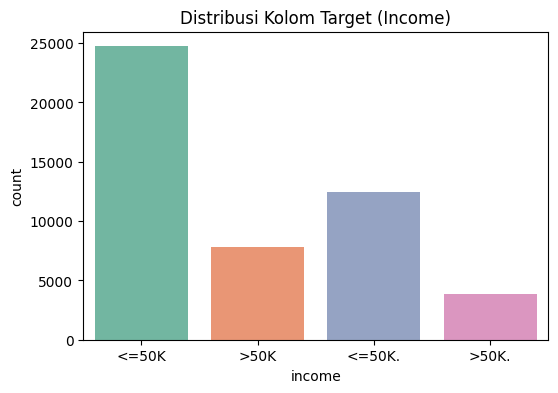

income
<=50K     50.612178
<=50K.    25.459645
>50K      16.053806
>50K.      7.874370
Name: proportion, dtype: float64


In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='income', hue='income', palette='Set2', legend=False)
plt.title("Distribusi Kolom Target (Income)")
plt.show()

print(df['income'].value_counts(normalize=True) * 100)

Memeriksa kolom Numerik dan Kategorik

In [14]:
# Mengelompokkan kolom berdasarkan tipe data
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorik = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Kolom Numerik: {kolom_numerik}")
print(f"Kolom Kategorik: {kolom_kategorik}")

Kolom Numerik: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Kolom Kategorik: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


Memeriksa outlier dan visualisasi data

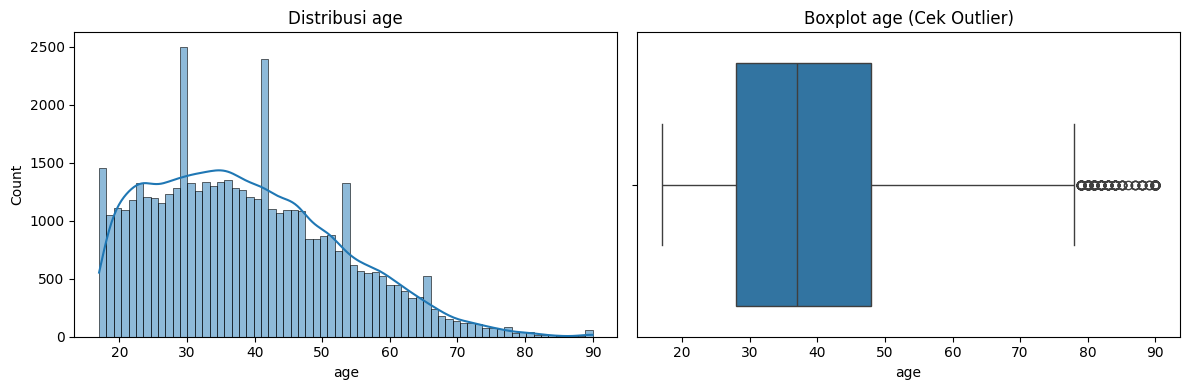

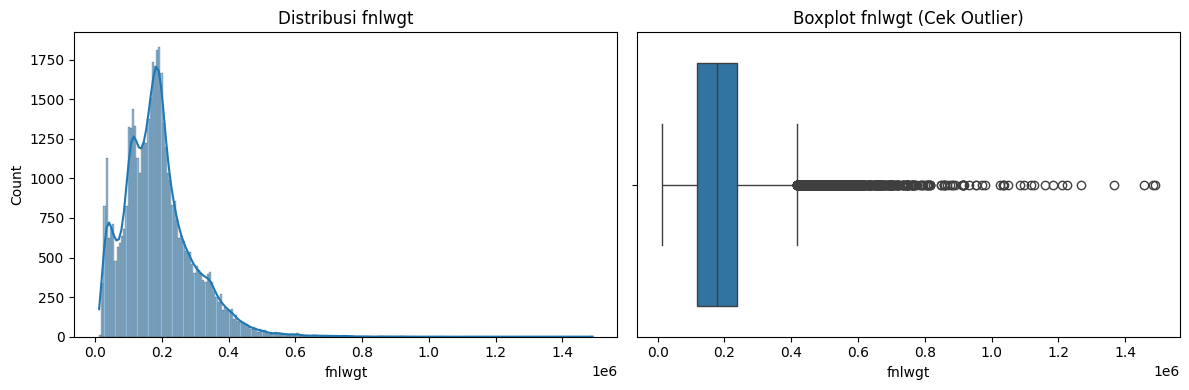

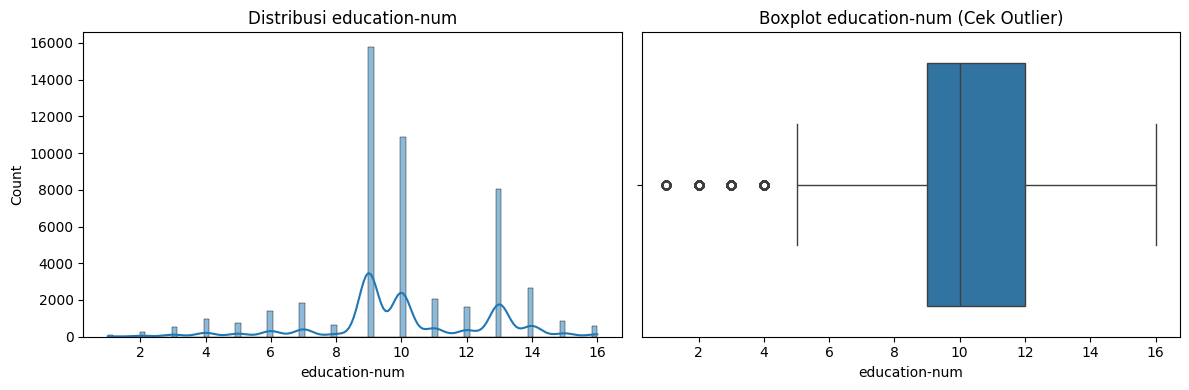

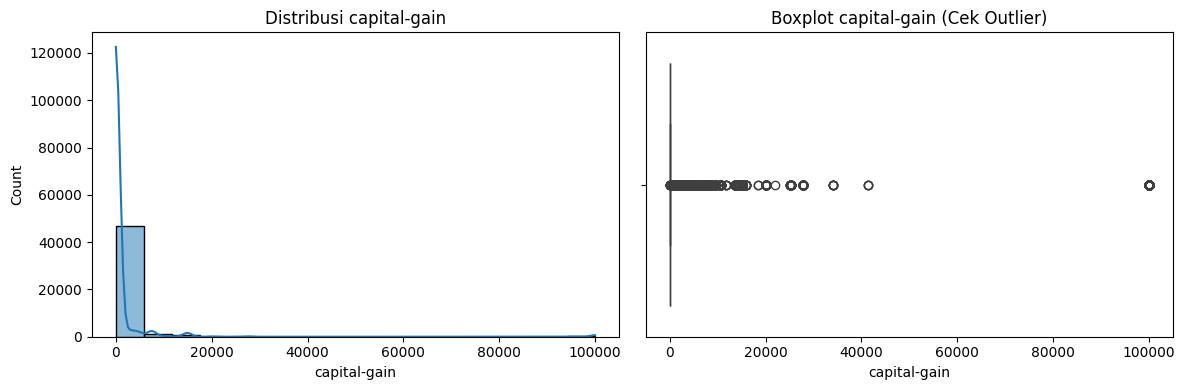

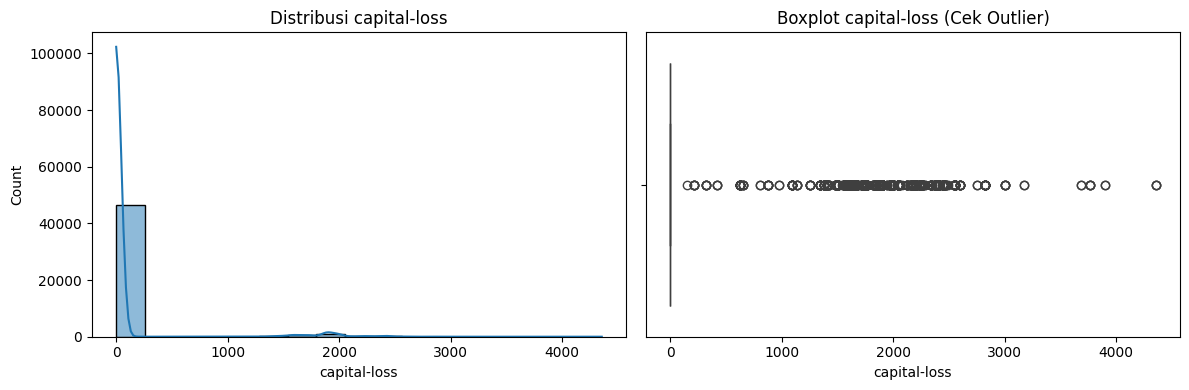

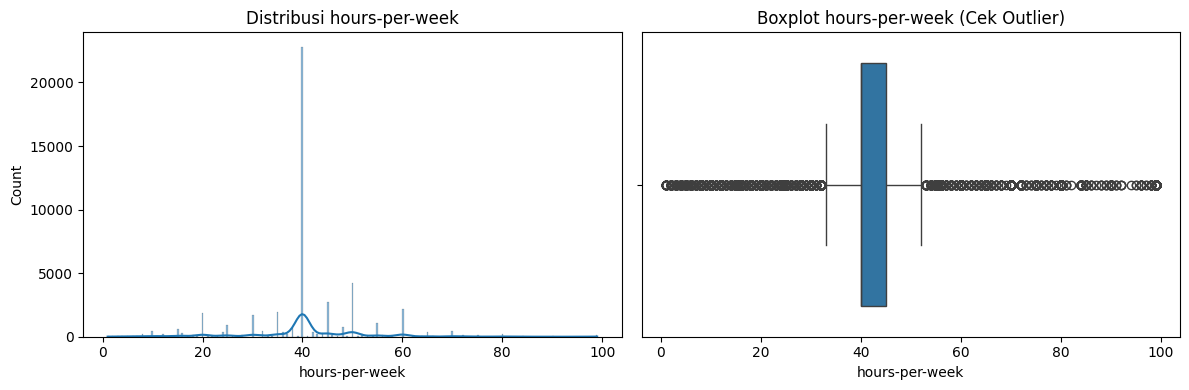

In [15]:
# Plot untuk kolom numerik (Histogram dan Boxplot)
for col in kolom_numerik:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram untuk distribusi
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"Distribusi {col}")

    # Boxplot untuk mengecek outlier
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Boxplot {col} (Cek Outlier)")

    plt.tight_layout()
    plt.show()

Kode Visualisasi Kategorik:

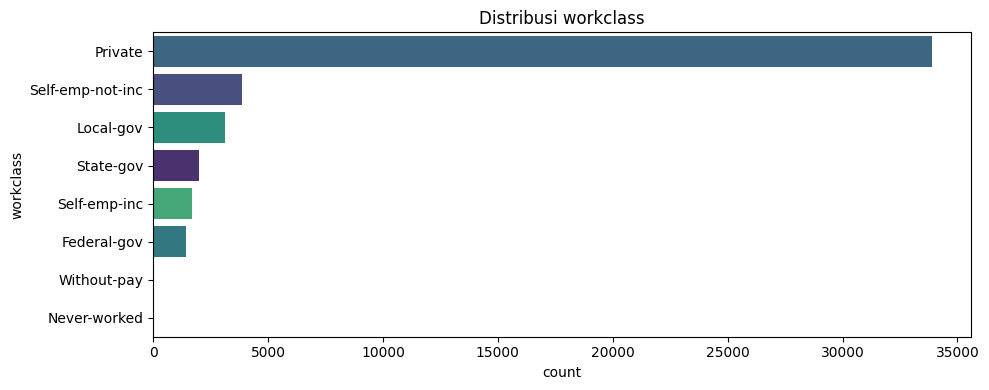

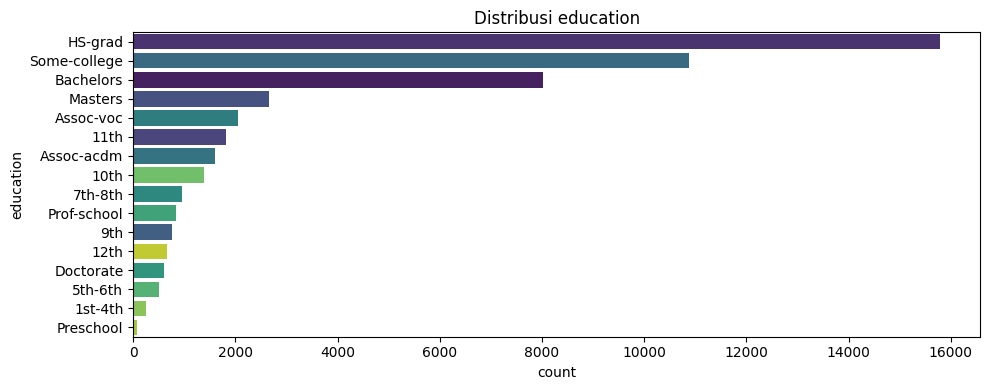

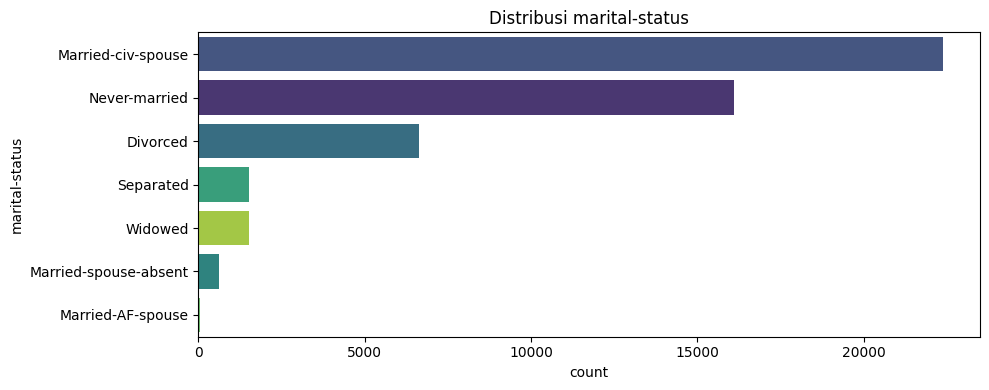

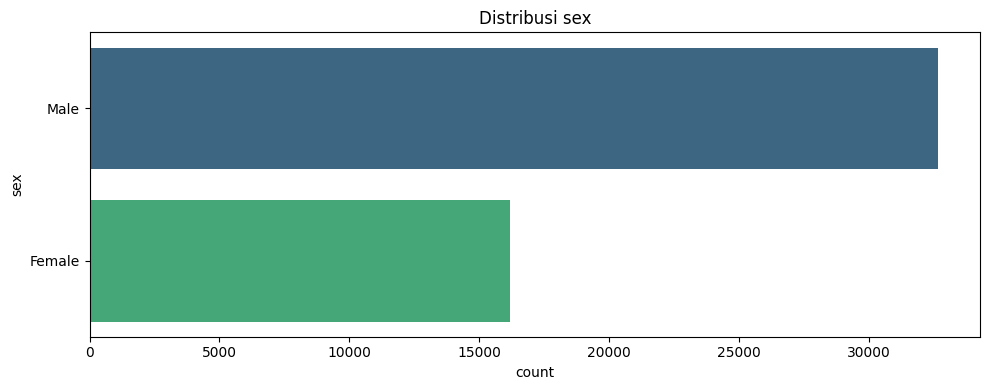

In [17]:
# Plot untuk beberapa kolom kategorik
kategorik_pilihan = ['workclass', 'education', 'marital-status', 'sex']

for col in kategorik_pilihan:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, y=col, hue=col, order=df[col].value_counts().index, palette='viridis', legend=False)
    plt.title(f"Distribusi {col}")
    plt.tight_layout()
    plt.show()

Kesimpulan:
Berdasarkan proses Exploratory Data Analysis (EDA) pada dataset Census Income, disimpulkan bahwa:

Dataset memiliki ukuran yang cukup besar, namun memiliki missing values pada kolom workclass, occupation, dan native_country (awalnya bersimbol ?).

Ditemukan adanya duplikasi data yang mungkin perlu dihapus.

Terdapat outlier pada variabel numerik finansial seperti capital_gain dan capital_loss.

Variabel target (income) mengalami imbalance, di mana pendapatan di bawah 50K mendominasi data. Fitur ini perlu diseimbangkan (resampling) sebelum masuk ke tahap machine learning.